# Evrards Collapse

Here we simulate the collapse of a gas sphere under its own gravity.

## Imports

In [ ]:
# ==== GPU selection ====
from autocvd import autocvd
autocvd(num_gpus = 1)
# ruff: noqa: E402
# =======================

# general
import jax.numpy as jnp

# astronomix constants
from astronomix import (
    REFLECTIVE_BOUNDARY
)

# astronomix containers
from astronomix import (
    SimulationConfig,
    SimulationParams,
    BoundarySettings,
    BoundarySettings1D,
    GravityConfig,
    SnapshotSettings,
    PositivityConfig
)

# astronomix functions
from astronomix import (
    get_helper_data,
    time_integration,
    construct_primitive_state,
    finalize_config,
    get_registered_variables
)

# plotting
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image

## Initiatization

In [2]:
gamma = 5/3

# spatial domain
box_size = 4.0
num_cells = 128

# setup simulation config
config = SimulationConfig(
    gravity_config = GravityConfig(
        self_gravity = True,
    ),
    positivity_config = PositivityConfig(
        preserving_flux = True,
    ),
    progress_bar = True,
    dimensionality = 3,
    box_size = box_size, 
    num_cells = num_cells,
    boundary_settings = BoundarySettings(
        BoundarySettings1D(
            left_boundary = REFLECTIVE_BOUNDARY,
            right_boundary = REFLECTIVE_BOUNDARY
        ),
        BoundarySettings1D(
            left_boundary = REFLECTIVE_BOUNDARY,
            right_boundary = REFLECTIVE_BOUNDARY
        ),
        BoundarySettings1D(
            left_boundary = REFLECTIVE_BOUNDARY,
            right_boundary = REFLECTIVE_BOUNDARY
        )
    )
)

helper_data = get_helper_data(config)

params = SimulationParams(
    t_end = 0.8,
    C_cfl = 0.8,
)

registered_variables = get_registered_variables(config)

## Setting the initial state

In [3]:
R = 1.0
M = 1.0

# initialize density field
num_injection_cells = jnp.sum(helper_data.r <= R)
rho = jnp.where(helper_data.r <= R, M / (2 * jnp.pi * R ** 2 * helper_data.r), 1e-4)

# Initialize velocity fields to zero
v_x = jnp.zeros_like(rho)
v_y = jnp.zeros_like(rho)
v_z = jnp.zeros_like(rho)

# initial thermal energy per unit mass = 0.05
e = 0.05
p = (gamma - 1) * rho * e

# Construct the initial primitive state for the 3D simulation.
initial_state = construct_primitive_state(
    config = config,
    registered_variables = registered_variables,
    density = rho,
    velocity_x = v_x,
    velocity_y = v_y,
    velocity_z = v_z,
    gas_pressure = p
)

In [4]:
config = finalize_config(config, initial_state.shape)

OPTIMAL_BACKEND: using the PALLAS backend (GPU compute capability >= 8.0).
Setting time integrator to RK4_SSP for finite difference solver mode.


## Simulation

In [5]:
final_state = time_integration(initial_state, config, params, registered_variables)

 |████████████████████████████████████████████████████████████████████| 100.0%  


## Visualization

### Slice

Text(0, 0.5, 'y')

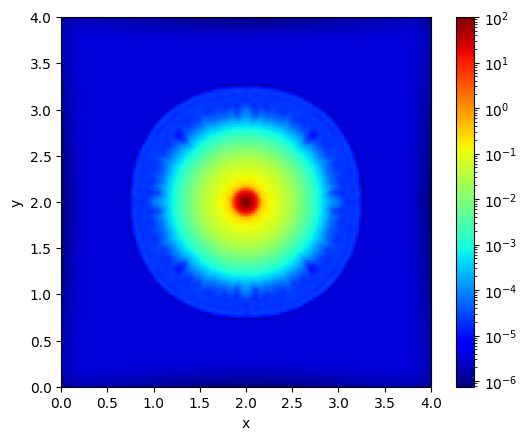

In [6]:
from matplotlib.colors import LogNorm

a = num_cells // 2 - 30
b = num_cells // 2 + 30

c = num_cells // 2 + 20
d = num_cells // 2 + 50

plt.imshow(
    jnp.abs(final_state[registered_variables.pressure_index, :, :, num_cells // 2].T),
    cmap = "jet", origin = "lower", extent=[0, box_size, 0, box_size], norm = LogNorm()
)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")

### Radial profiles

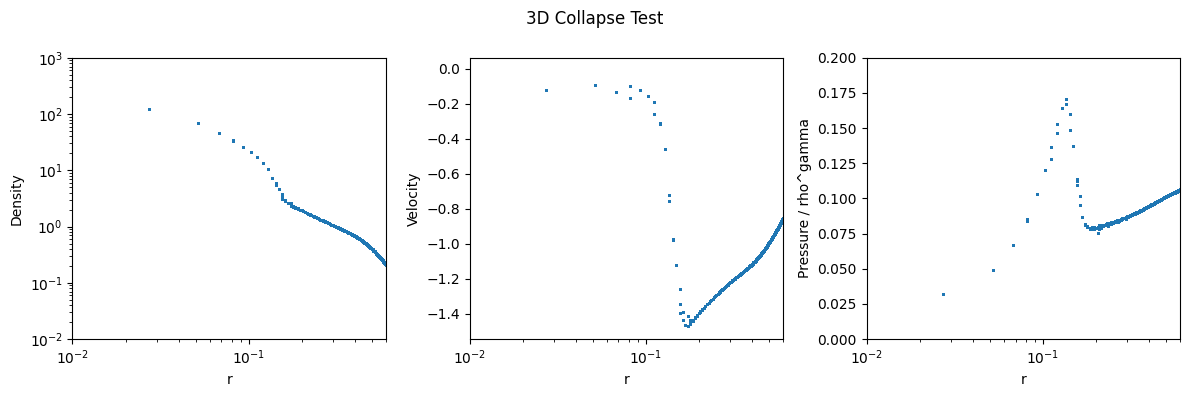

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(
    helper_data.r.flatten(),
    final_state[registered_variables.density_index].flatten(),
    label="Final Density", s = 1
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(1e-2, 6e-1)
ax1.set_ylim(1e-2, 1e3)
ax1.set_xlabel("r")
ax1.set_ylabel("Density")

# velocity profile
v_r = -jnp.sqrt(
    final_state[registered_variables.velocity_index.x] ** 2 + 
    final_state[registered_variables.velocity_index.y] ** 2 + 
    final_state[registered_variables.velocity_index.z] ** 2
)

ax2.scatter(helper_data.r.flatten(), v_r.flatten(), label="Radial Velocity", s = 1)
ax2.set_xscale("log")
ax2.set_xlim(1e-2, 6e-1)
ax2.set_xlabel("r")
ax2.set_ylabel("Velocity")

ax3.scatter(helper_data.r.flatten(), final_state[registered_variables.pressure_index].flatten() / final_state[registered_variables.density_index].flatten() ** gamma, label="P / rho^gamma", s = 1)
ax3.set_xlabel("r")
ax3.set_ylabel("Pressure / rho^gamma")
ax3.set_xscale("log")
ax3.set_xlim(1e-2, 6e-1)
ax3.set_ylim(0, 0.2)

fig.suptitle("3D Collapse Test")

plt.tight_layout()

## Check energy conservation

In [8]:
config = config._replace(
    return_snapshots = True,
    num_snapshots = 60,
    snapshot_settings = SnapshotSettings(
        return_states = True,
        return_total_energy = True,
        return_kinetic_energy = True,
        return_internal_energy = True,
        return_gravitational_energy = True,
    )

)
params = params._replace(t_end = 3.0)

In [9]:
snapshots = time_integration(initial_state, config, params, registered_variables)

 |████████████████████████████████████████████████████████████████████| 100.0%  


In [10]:
total_energy = snapshots.total_energy
internal_energy = snapshots.internal_energy
kinetic_energy = snapshots.kinetic_energy
gravitational_energy = snapshots.gravitational_energy
time = snapshots.time_points

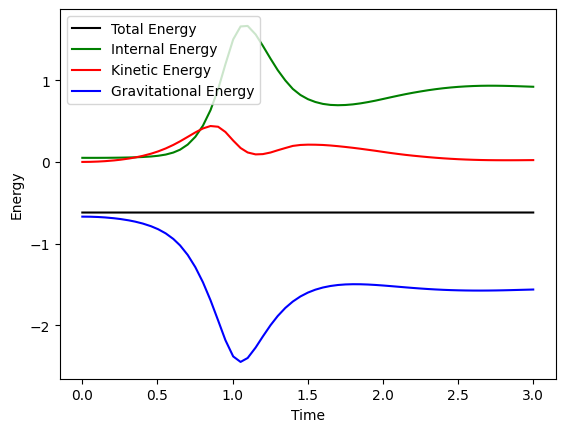

In [11]:
t_end = 3.0
plt.plot(time, total_energy, label="Total Energy", color = "black")
plt.plot(time, internal_energy, label="Internal Energy", color = "green")
plt.plot(time, kinetic_energy, label="Kinetic Energy", color = "red")
plt.plot(time, gravitational_energy, label="Gravitational Energy", color = "blue")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()

plt.savefig("collapse_conservation.svg")

## Animation

In [12]:
fig, ax = plt.subplots()

def animate(i):
    ax.clear()
    state = snapshots.states[i]
    im = ax.imshow(state[0, :, :, num_cells // 2].T, cmap="jet", origin="lower", extent=[0, box_size, 0, box_size], norm=LogNorm())
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Density at time {time[i]:.2f}")
    return [im]

ani = animation.FuncAnimation(fig, animate, frames=len(snapshots.states), interval=100, blit=True)
plt.colorbar(ax.imshow(snapshots.states[0][0, :, :, num_cells // 2].T, cmap="jet", origin="lower", extent=[0, box_size, 0, box_size], norm=LogNorm()), ax=ax)
# save to gif
ani.save("3d_collapse.gif")
plt.close(fig)

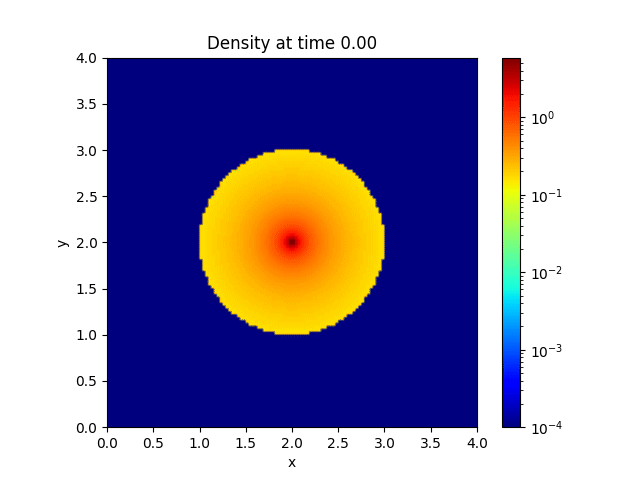

In [13]:
Image(filename='3d_collapse.gif')